# Predicting Hotel Booking Cancellations

## Project Overview

This project aims to build a machine learning workflow to predict whether a hotel booking will be cancelled.

The dataset contains hotel reservation records with customer, booking and stay related features. The target variable is `booking status` which is either cancelled or not cancelled.

The goal is to train and evaluate classification models that can estimate cancellation risk before the guest arrives. This could help hotels make better decisions about overbooking, staffing, pricing, and customer follow-up.

## Import Libraries and load dataset

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

In [3]:
# Load Dataset
df = pd.read_csv("booking.csv")
df.head()

,Booking_ID,number of adults,number of children,number of weekend nights,number of week nights,type of meal,car parking space,room type,lead time,market segment type,repeated,P-C,P-not-C,average price,special requests,date of reservation,booking status
0,INN00001,1,1,2,5,Meal Plan 1,0,Room_Type 1,224,Offline,0,0,0,88.00,0,10/2/2015,Not_Canceled
1,INN00002,1,0,1,3,Not Selected,0,Room_Type 1,5,Online,0,0,0,106.68,1,11/6/2018,Not_Canceled
2,INN00003,2,1,1,3,Meal Plan 1,0,Room_Type 1,1,Online,0,0,0,50.00,0,2/28/2018,Canceled
3,INN00004,1,0,0,2,Meal Plan 1,0,Room_Type 1,211,Online,0,0,0,100.00,1,5/20/2017,Canceled
4,INN00005,1,0,1,2,Not Selected,0,Room_Type 1,48,Online,0,0,0,77.00,0,4/11/2018,Canceled


## Exploratory Data Analysis

### Data types and shape

In [8]:
df.shape

(36285, 17)

There are 36285 rows each representing a booking. There are 17 columns.

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 36285 entries, 0 to 36284
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Booking_ID                36285 non-null  str    
 1   number of adults          36285 non-null  int64  
 2   number of children        36285 non-null  int64  
 3   number of weekend nights  36285 non-null  int64  
 4   number of week nights     36285 non-null  int64  
 5   type of meal              36285 non-null  str    
 6   car parking space         36285 non-null  int64  
 7   room type                 36285 non-null  str    
 8   lead time                 36285 non-null  int64  
 9   market segment type       36285 non-null  str    
 10  repeated                  36285 non-null  int64  
 11  P-C                       36285 non-null  int64  
 12  P-not-C                   36285 non-null  int64  
 13  average price             36285 non-null  float64
 14  special requests 

We see the data types above all seem to make sense.

### Summary Statistics

In [9]:
df.describe()

,number of adults,number of children,number of weekend nights,number of week nights,car parking space,lead time,repeated,P-C,P-not-C,average price,special requests
count,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000
mean,1.844839,0.105360,0.810693,2.204602,0.030977,85.239851,0.025630,0.023343,0.153369,103.421636,0.619733
std,0.518813,0.402704,0.870590,1.410946,0.173258,85.938796,0.158032,0.368281,1.753931,35.086469,0.786262
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,0.000000,1.000000,0.000000,17.000000,0.000000,0.000000,0.000000,80.300000,0.000000
50%,2.000000,0.000000,1.000000,2.000000,0.000000,57.000000,0.000000,0.000000,0.000000,99.450000,0.000000
75%,2.000000,0.000000,2.000000,3.000000,0.000000,126.000000,0.000000,0.000000,0.000000,120.000000,1.000000
max,4.000000,10.000000,7.000000,17.000000,1.000000,443.000000,1.000000,13.000000,58.000000,540.000000,5.000000


The minimum value of 0 for the average price may be an issue with the data, but could just be a few instances of free rooms. 
Similarly, a booking with zero week nights and zero weekend nights could suggest some incorrect data. Lets see how many of these there are:

In [17]:
zero_nights = (
    (df["number of weekend nights"] == 0) & 
    (df["number of week nights"] == 0)
).sum()

zero_price = (df["average price"] == 0).sum()

print(f"There are {zero_nights} bookings with zero total nights")
print(f"There are {zero_price} bookings with an average price of zero")

There are 78 bookings with zero total nights
There are 545 bookings with an average price of zero


There are very few bookings with zero nights in a dataset with 36285 bookings in total, so this should not be an issue. There are slightly more with zero average price but this seems fine since there are some valid reasons for rooms being free.

### Missing Values

In [21]:
print(df.isnull().sum())

Booking_ID                  0
number of adults            0
number of children          0
number of weekend nights    0
number of week nights       0
type of meal                0
car parking space           0
room type                   0
lead time                   0
market segment type         0
repeated                    0
P-C                         0
P-not-C                     0
average price               0
special requests            0
date of reservation         0
booking status              0
dtype: int64


There are no missing values recorded as NaN. This is good, but perhaps some of the unexpected zero values in number of nights and average price are missing values.

Lets look at how many unique values each column has.  

### Unique Values

In [18]:
df.nunique().sort_values()

car parking space               2
repeated                        2
booking status                  2
type of meal                    4
market segment type             5
number of adults                5
number of children              6
special requests                6
room type                       7
number of weekend nights        8
P-C                             9
number of week nights          18
P-not-C                        59
lead time                     352
date of reservation           553
average price                3930
Booking_ID                  36285
dtype: int64

From this we can see `car parking space`, `repeated`, and `booking status` are binary columns. `booking status` is the target variable so we are dealing with a binary classification problem.
The columns `type of meal`, `market segment type`, and `room type` have a small number of values and are categorical variables that will need encoding.
Booking_ID is an identifier that will not help our models. So it should be dropped before model training.

### Data Visualisation

First we look at the distribution of the target variable `booking status`

In [26]:
print(df["booking status"].value_counts())
print(df["booking status"].value_counts(normalize=True) * 100)

booking status
Not_Canceled    24396
Canceled        11889
Name: count, dtype: int64
booking status
Not_Canceled    67.234394
Canceled        32.765606
Name: proportion, dtype: float64


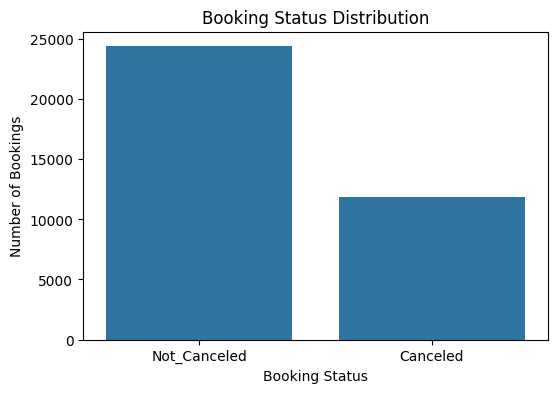

In [24]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="booking status")
plt.title("Booking Status Distribution")
plt.xlabel("Booking Status")
plt.ylabel("Number of Bookings")
plt.show()

We can see that most bookings were not cancelled (67%). This is a bit imbalanced, but there should be enough cancelled bookings for the models to learn patterns. When evaluating the performance of the model, we will need to look at metrics other than just accuracy.

#### Correlation

Now lets look at how booking status relates to other variables. To calculate correlations we need booking status to be numeric. We create a column `canceled_binary` where 1 = cancelled and 0 = not cancelled. 

In [28]:
df["canceled_binary"] = df["booking status"].map({"Not_Canceled": 0, "Canceled": 1})
numeric_corr = df.select_dtypes(include=["int64", "float64"]).corr()
numeric_corr["canceled_binary"].sort_values(ascending=False)

canceled_binary             1.000000
lead time                   0.438491
average price               0.142433
number of week nights       0.092824
number of adults            0.086774
number of weekend nights    0.061489
number of children          0.033007
P-C                        -0.033725
P-not-C                    -0.060174
car parking space          -0.086179
repeated                   -0.107277
special requests           -0.253092
Name: canceled_binary, dtype: float64

The correlation results show that `lead time` has the strongest positive relationship with booking cancellation. This suggests that bookings made further in advance are more likely to be cancelled.
`average price` also has a positive correlation with cancellation, although the relationship is weaker. This may suggest that more expensive bookings are slightly more likely to be cancelled.

`special requests` has the strongest negative correlation with cancellation. This suggests that bookings with more special requests are less likely to be cancelled, possibly because these customers are more committed to their stay.

Now lets look at correlation between features to check for multicollinearity.

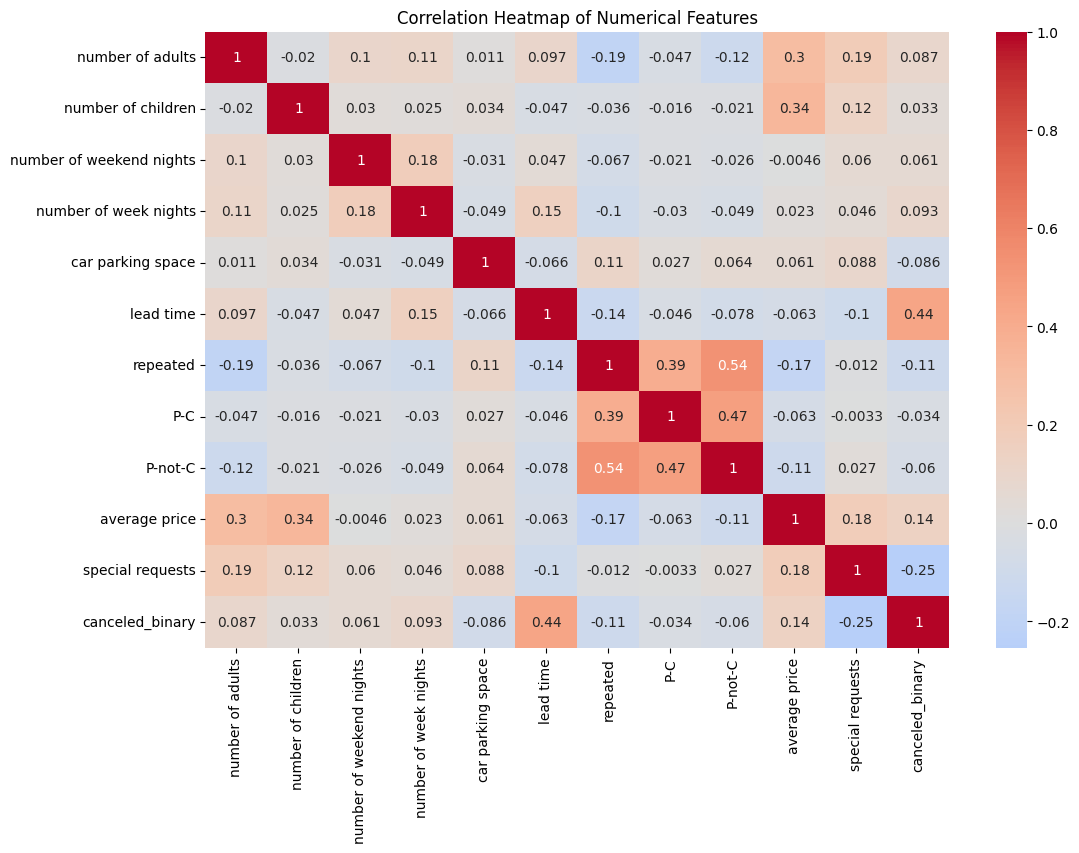

In [43]:
numeric_corr = df.select_dtypes(include=["int64", "float64"]).corr()
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

No extremely high correlations were found between most numerical input features, so I will keep the features for now and allow the modelling stage to determine their usefulness. There are a few moderately high correlations so it may be worth coming back to when looking at logistic regression.

#### Categorical variable relationships with cancellation 

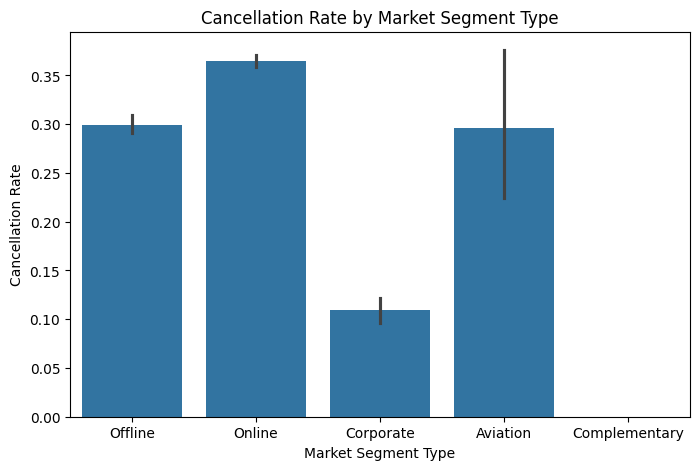

In [33]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="market segment type", y="canceled_binary")
plt.title("Cancellation Rate by Market Segment Type")
plt.xlabel("Market Segment Type")
plt.ylabel("Cancellation Rate")
plt.show()

For `market segment type`, online bookings have the highest cancellation rate at around 36.5%, followed by offline and aviation bookings. Corporate bookings have a much lower cancellation rate at around 10.9%, while complementary bookings have a cancellation rate of 0%. This suggests that market segment type may be an important predictor of booking cancellations.

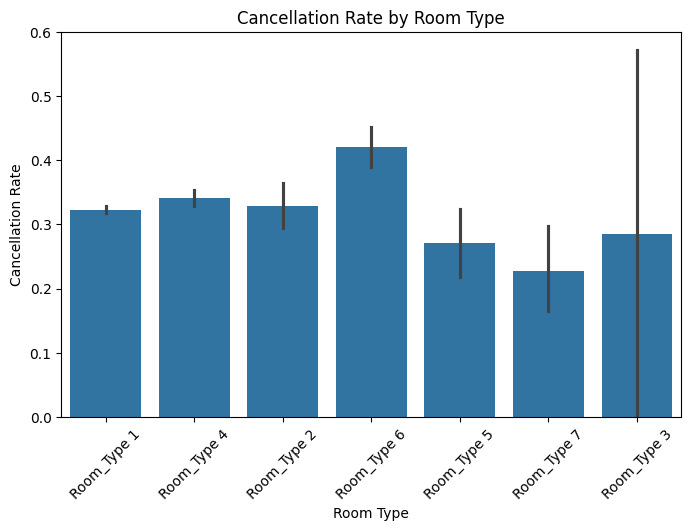

In [35]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="room type", y="canceled_binary")
plt.title("Cancellation Rate by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Cancellation Rate")
plt.xticks(rotation=45)
plt.show()

For `room type`, cancellation rates vary between room categories. `Room_Type 6` has the highest cancellation rate at around 42.0%, while `Room_Type 7` has the lowest at around 22.8%. This suggests that room type may contain useful information for predicting cancellations, although the differences are not as large as some other features.

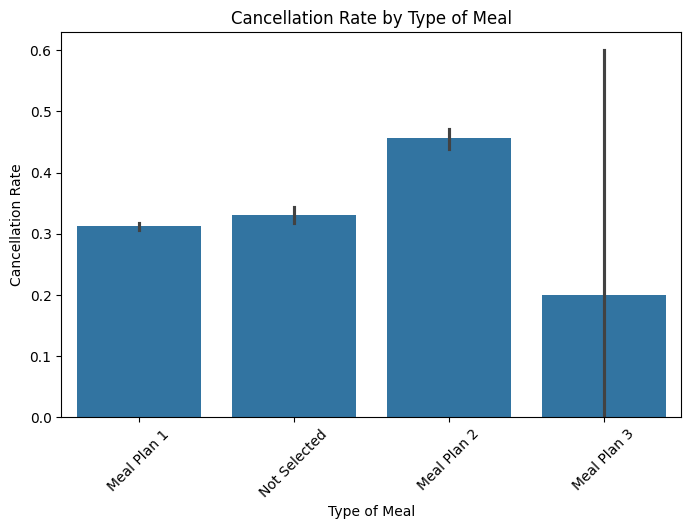

In [37]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="type of meal", y="canceled_binary")
plt.title("Cancellation Rate by Type of Meal")
plt.xlabel("Type of Meal")
plt.ylabel("Cancellation Rate")
plt.xticks(rotation=45)
plt.show()

For `type of meal`, bookings with `Meal Plan 2` have the highest cancellation rate at around 45.6%, while `Meal Plan 3` has the lowest cancellation rate at 20.0%. 

These results indicate that categorical features should be included in the model and encoded during preprocessing.

## Data Processing

First lets create a modelling copy and remove the temporary `canceled_binary` column we created during EDA.

In [75]:
df_model = df.copy()
df_model = df_model.drop(columns=["canceled_binary"])

We should clean the column names by replacing the spaces and dashes between words with "_", removing any additional whitespace, and making all lower case. Also, we decided we should remove the booking_id column.

In [76]:
df_model.columns = (df_model.columns.str.strip().str.lower().str.replace(" ", "_").str.replace("-", "_"))
df_model = df_model.drop(columns=["booking_id"])
df_model.head()

,number_of_adults,number_of_children,number_of_weekend_nights,number_of_week_nights,type_of_meal,car_parking_space,room_type,lead_time,market_segment_type,repeated,p_c,p_not_c,average_price,special_requests,date_of_reservation,booking_status
0,1,1,2,5,Meal Plan 1,0,Room_Type 1,224,Offline,0,0,0,88.00,0,10/2/2015,Not_Canceled
1,1,0,1,3,Not Selected,0,Room_Type 1,5,Online,0,0,0,106.68,1,11/6/2018,Not_Canceled
2,2,1,1,3,Meal Plan 1,0,Room_Type 1,1,Online,0,0,0,50.00,0,2/28/2018,Canceled
3,1,0,0,2,Meal Plan 1,0,Room_Type 1,211,Online,0,0,0,100.00,1,5/20/2017,Canceled
4,1,0,1,2,Not Selected,0,Room_Type 1,48,Online,0,0,0,77.00,0,4/11/2018,Canceled


### Removing stays with zero nights

We noticed in the EDA that some bookings have zero week nights and zero weekend nights. Lets create a total length of stay feature:

In [77]:
df_model["total_nights"] = (df_model["number_of_weekend_nights"] + df_model["number_of_week_nights"])
print((df_model["total_nights"] == 0).sum())

78


We can now remove bookings with zero nights as this does not represent an actual stay at a hotel

In [78]:
df_model = df_model[df_model["total_nights"] > 0]

### Transforming `date_of_reservation`

In our EDA we saw the data type for the dates is string. We convert this to datetime:

In [79]:
df_model["date_of_reservation"] = pd.to_datetime(df_model["date_of_reservation"], errors="coerce")

In [80]:
print(f"{df_model["date_of_reservation"].isna().sum()} failed to convert")

37 failed to convert


Since 37 is a very small proportion of the total data set, I will remove the rows with invalid dates before creating date features.

In [81]:
df_model = df_model.dropna(subset=["date_of_reservation"])
df_model["date_of_reservation"].isna().sum()

np.int64(0)

Now we can create 3 date features:

In [82]:
df_model["reservation_year"] = df_model["date_of_reservation"].dt.year
df_model["reservation_month"] = df_model["date_of_reservation"].dt.month
df_model["reservation_day_of_week"] = df_model["date_of_reservation"].dt.dayofweek

Then remove the original data column:

In [83]:
df_model = df_model.drop(columns=["date_of_reservation"])

### Encoding the target variable

In [84]:
df_model["booking_status"] = df_model["booking_status"].map({"Not_Canceled": 0,"Canceled": 1})
print(df_model["booking_status"].value_counts())

booking_status
0    24290
1    11880
Name: count, dtype: int64


We now have "booking_status" encoded with 0 representing Not_Canceled bookings and 1 representing Canceled bookings.

### Separate features and target

In [87]:
X = df_model.drop(columns=["booking_status"])
y = df_model["booking_status"]

### Identify numeric and categorical features

This is done so that we can scale numeric features, and one-hot encode categorical features later.

In [91]:
numeric_features = X.select_dtypes(include=["int64", "float64", "int32"]).columns.tolist()
categorical_features = X.select_dtypes(include=["str"]).columns.tolist()

print("Numeric features:")
print(numeric_features)

print("Categorical features:")
print(categorical_features)

Numeric features:
['number_of_adults', 'number_of_children', 'number_of_weekend_nights', 'number_of_week_nights', 'car_parking_space', 'lead_time', 'repeated', 'p_c', 'p_not_c', 'average_price', 'special_requests', 'total_nights', 'reservation_year', 'reservation_month', 'reservation_day_of_week']
Categorical features:
['type_of_meal', 'room_type', 'market_segment_type']


### Train-Validation-Test split

In [93]:
X_train_validation, X_test, y_train_validation, y_test = train_test_split(X, y, test_size=0.2, random_state=1, stratify=y)

Stratify=y was used because of the imbalance between cancelled and not cancelled rooms. This means the proportion of cancelled and non-cancelled bookings is similar in both the training and test sets.

In [96]:
X_train, X_val, y_train, y_val = train_test_split(X_train_validation, y_train_validation, test_size=0.25, random_state=1, stratify=y_train_validation)

The data was split into training, validation, and test sets. The training set will be used to fit the models, the validation set will be used to compare models and tune hyperparameters, and the test set will be held back until the final evaluation.

### Preprocessing pipeline

In [100]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

## Model Training and Validation

In [101]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=1),
    "Decision Tree": DecisionTreeClassifier(random_state=1),
    "Random Forest": RandomForestClassifier(random_state=1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=1)
}

In [102]:
results = []

for model_name, model in models.items():
    pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("classifier", model)])
    pipeline.fit(X_train, y_train)

    y_val_pred = pipeline.predict(X_val)
    y_val_proba = pipeline.predict_proba(X_val)[:, 1]

    results.append({
        "model": model_name,
        "accuracy": accuracy_score(y_val, y_val_pred),
        "precision": precision_score(y_val, y_val_pred),
        "recall": recall_score(y_val, y_val_pred),
        "f1": f1_score(y_val, y_val_pred),
        "roc_auc": roc_auc_score(y_val, y_val_proba)
    })

results_df = pd.DataFrame(results).sort_values("f1", ascending=False)
results_df

,model,accuracy,precision,recall,f1,roc_auc
2,Random Forest,0.890102,0.868875,0.783670,0.824076,0.945504
1,Decision Tree,0.857202,0.785623,0.777357,0.781468,0.840334
3,Gradient Boosting,0.849876,0.809204,0.710438,0.756611,0.908662
0,Logistic Regression,0.806469,0.737817,0.637205,0.683830,0.859682


Different models were compared on the validation data. The Random Forest model has the highest accuracy, and importantly due to the imbalanced data. the highest f1-score. It also has the highest scores for all the other metrics as well. We will chose this as our best model moving forward.

In [105]:
best_model = models["Random Forest"]
best_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", best_model)
])
best_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

Lets inspect the best model further. Here is the confusion matrix:

In [110]:
y_val_pred = best_pipeline.predict(X_val)
y_val_proba = best_pipeline.predict_proba(X_val)[:, 1]

cm = confusion_matrix(y_val, y_val_pred)
cm_df = pd.DataFrame(
    cm,
    index=["Actual Not Canceled", "Actual Canceled"],
    columns=["Predicted Not Canceled", "Predicted Canceled"]
)

cm_df

,Predicted Not Canceled,Predicted Canceled
Actual Not Canceled,4577,281
Actual Canceled,514,1862


### Hyperparameter Tuning

We will use a grid search to find the best parameters for the Random Forest model.

In [113]:
param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [None, 10, 20],
    "classifier__min_samples_split": [2, 5],
    "classifier__min_samples_leaf": [1, 2]
}

grid_search = GridSearchCV(best_pipeline, param_grid=param_grid, cv=5, scoring="f1",n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Estimator:", grid_search.best_estimator_)

Best Parameters: {'classifier__max_depth': 20, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}
Best Estimator: Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['number_of_adults',
                                                   'number_of_children',
                                                   'number_of_weekend_nights',
                                                   'number_of_week_nights',
                                                   'car_parking_space',
                           

In [114]:
best_rf_model = grid_search.best_estimator_

y_val_pred_tuned = best_rf_model.predict(X_val)
y_val_proba_tuned = best_rf_model.predict_proba(X_val)[:, 1]

print(classification_report(y_val, y_val_pred_tuned))

              precision    recall  f1-score   support

           0       0.90      0.94      0.92      4858
           1       0.87      0.78      0.82      2376

    accuracy                           0.89      7234
   macro avg       0.88      0.86      0.87      7234
weighted avg       0.89      0.89      0.89      7234



In [116]:
tuned_rf_results = [{
    "model": "Tuned Random Forest",
    "accuracy": accuracy_score(y_val, y_val_pred_tuned),
    "precision": precision_score(y_val, y_val_pred_tuned),
    "recall": recall_score(y_val, y_val_pred_tuned),
    "f1": f1_score(y_val, y_val_pred_tuned),
    "roc_auc": roc_auc_score(y_val, y_val_proba_tuned)
}]

tuned_results_df = pd.DataFrame(tuned_rf_results).sort_values("f1", ascending=False)
tuned_results_df

,model,accuracy,precision,recall,f1,roc_auc
0,Tuned Random Forest,0.888582,0.867166,0.780303,0.821444,0.945776


The tuned Random Forest model did not improve validation performance compared with the original Random Forest model. Although the tuned model had a slightly higher ROC-AUC score, its F1-score, recall, precision, and accuracy were slightly lower.
Since F1-score was selected as an important metric for this project, we will keep the original Random Forest model as the final model.

### Final Model Evaluation

In [117]:
final_model = Pipeline(steps=[("preprocessor", preprocessor),("classifier", RandomForestClassifier(random_state=1))])

Having used the validation set for hyperparameter tuning, we will combine it with the training data for fitting the final model on the full training set.

In [118]:
final_model.fit(X_train_validation, y_train_validation)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

The final evaluation will be done on the test data set which has not been used so far.

In [119]:
y_test_pred = final_model.predict(X_test)
y_test_proba = final_model.predict_proba(X_test)[:, 1]

test_results = {
    "model": "Final Random Forest",
    "accuracy": accuracy_score(y_test, y_test_pred),
    "precision": precision_score(y_test, y_test_pred),
    "recall": recall_score(y_test, y_test_pred),
    "f1": f1_score(y_test, y_test_pred),
    "roc_auc": roc_auc_score(y_test, y_test_proba)
}

test_results

{'model': 'Final Random Forest',
 'accuracy': 0.9033729610174177,
 'precision': 0.8792401628222524,
 'recall': 0.8181818181818182,
 'f1': 0.8476128188358404,
 'roc_auc': 0.9561465658367675}

In [120]:
cm = confusion_matrix(y_test, y_test_pred)

cm_df = pd.DataFrame(
    cm,
    index=["Actual Not Canceled", "Actual Canceled"],
    columns=["Predicted Not Canceled", "Predicted Canceled"]
)

cm_df

,Predicted Not Canceled,Predicted Canceled
Actual Not Canceled,4591,267
Actual Canceled,432,1944


## Key Findings

### EDA

The dataset contained 36,285 hotel reservation records before cleaning. The target variable was somewhat imbalanced, with more non-cancelled bookings than cancelled bookings. Some unusual records were found, particularly bookings with zero total nights. Zero-night bookings were removed during preprocessing.
A few potential relationships were identified:
- Bookings with longer lead times were more likely to be cancelled.
- Bookings with more special requests were less likely to be cancelled.
- Market segment type appeared to influence cancellation behaviour, with online bookings showing the highest cancellation rate corporate bookings showing the lowest.


### Modelling Process

I compared several classification models using the same preprocessing pipeline:

- Logistic Regression
- Decision Tree
- Random Forest
- Gradient Boosting

The data was split into training, validation, and test sets. The training set was used to fit the models, the validation set was used to compare model performance, and the test set was reserved for the final evaluation.
The preprocessing pipeline scaled numerical features and one-hot encoded categorical features.

The Random Forest model performed best on the validation data, with strong performance across accuracy, precision, recall, F1-score, and ROC-AUC.

The hyperparameters were tested using GridSearchCV. However, the tuned Random Forest did not improve the validation F1-score compared with the original Random Forest model. Because of this, I selected the original Random Forest as the final model.

### Test Results

The final Random Forest model was evaluated on the untouched test set.

| Metric | Score |
|---|---:|
| Accuracy | 0.903 |
| Precision | 0.879 |
| Recall | 0.818 |
| F1-score | 0.848 |
| ROC-AUC | 0.956 |

The model performed well on the test set, suggesting that it generalised effectively to unseen booking records. Since the results on the test data are similar to the results on the validation data, the model is unlikely to be overfitting to the training data.

#### Confusion Matrix Interpretation

- True negatives: 4591
- False positives: 267
- False negatives: 432
- True positives: 1944

The model correctly predicted 4,591 bookings that were not cancelled.
The model correctly predicted 1,944 bookings that were cancelled.
It incorrectly predicted 267 bookings as cancelled when they were actually not cancelled.
It missed 432 actual cancellations, predicting them as not cancelled.

This seems a good balance and could be useful for hotels looking to identify cancellation risk. The importance of the errors will depend on the business goals. One option would be to adjust the model to try and decrease the number of false negatives if the business wants to prioritise identifying potential cancellation risks. However, this would likely result in more false positives, meaning the business would need to be ok with more bookings being flagged as cancellation risks and the customers still showing up. 

## Limitations and Next steps

This project has some limitations. The model was trained on historical booking data, so its performance may change if customer behaviour or hotel policies change over time.
The dataset also does not include some potentially useful information, such as customer communication history, competitor pricing, local events, or weather conditions.

Future improvements could include:

- Testing additional models such as Support Vector Machine or Naive Bayes
- Tuning the classification threshold to prioritise either precision or recall
- Analysing feature importance to better understand the final model's predictions


## Conclusion

This project built an end-to-end machine learning workflow for predicting hotel booking cancellations. 
The final Random Forest model performed well and showed that booking cancellation risk can be predicted using reservation and customer-related features. These predictions could help hotels make better business decisions around booking management, customer follow-up, and resource planning.